# COVID-19 HLA × TCR Biomarker Analysis

Replication of **HLA class II association** reported in Vlasova *et al.* (2026)
*Genome Med.* [DOI:10.1186/s13073-025-01589-4](https://doi.org/10.1186/s13073-025-01589-4)
using 1 137 paired AIRR donors (761 COVID-19 / 376 healthy).

Two complementary analyses are run:

1. **DRB1\*16 / DQB1\*05 stratified scan** — Fisher tests within HLA-stratified
   sub-cohorts to detect clonotypes enriched specifically under MHC class II restriction.
   Includes a focused TRBV12-3/CASS replication test with pre-specified multiple-testing
   correction.
2. **HLA allele × global biomarker presence** — for each of the 43 globally significant
   CDR3s (from `covid19_biomarkers.ipynb`), test association with 83 common HLA alleles
   across 3 569 pairs.


## 1. Setup

In [1]:
from __future__ import annotations
import json, sys, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

SEED = 42
np.random.seed(SEED)
FDR_THRESHOLD  = 0.05
MIN_ALLELE_N   = 30          # minimum donors per allele to include in analysis
VDJDB_PATH     = Path(__file__).resolve().parent.parent if '__file__' in dir() else Path.cwd()

def find_repo_root(start=None):
    here = (start or Path.cwd()).resolve()
    for cand in (here, *here.parents):
        if (cand / 'pyproject.toml').exists() and (cand / 'mir').exists():
            return cand
    raise FileNotFoundError('Cannot find repo root')

repo_root  = find_repo_root()
data_root  = repo_root / 'notebooks' / 'assets' / 'large' / 'airr_covid19'
tmp_dir    = repo_root / 'tmp'
assets_dir = repo_root / 'notebooks' / 'assets'
vdjdb_path = repo_root / 'airr_benchmark' / 'vdjdb' / 'vdjdb-2025-12-29' / 'vdjdb_full.txt.gz'

import importlib.metadata
print(f'Python {sys.version.split()[0]}  mirpy-lib {importlib.metadata.version("mirpy-lib")}')
print(f'numpy {np.__version__}  pandas {pd.__version__}')
print(f'data_root:  {data_root.exists()}')
print(f'vdjdb:      {vdjdb_path.exists()}')


Python 3.11.15  mirpy-lib 1.1.1
numpy 2.4.6  pandas 2.3.3
data_root:  True
vdjdb:      True


## 2. Load Significant Biomarker Clonotypes

In [2]:
# Load global Fisher scan results and show significant hits per locus.
fisher_trb = pd.read_parquet(tmp_dir / 'fisher_trb.parquet')
fisher_tra = pd.read_parquet(tmp_dir / 'fisher_tra.parquet')

sig_trb = fisher_trb[fisher_trb['p_value_adj'] < FDR_THRESHOLD].copy()
sig_tra = fisher_tra[fisher_tra['p_value_adj'] < FDR_THRESHOLD].copy()
sig_all = pd.concat([sig_trb.assign(locus='TRB'), sig_tra.assign(locus='TRA')], ignore_index=True)

print(f'Global Fisher scan — significant CDR3s (q<{FDR_THRESHOLD}):')
print(f'  TRB: {len(sig_trb)}  '
      f'(COVID-enriched: {(sig_trb.log2_fe>0).sum()}, healthy-enriched: {(sig_trb.log2_fe<0).sum()})')
print(f'  TRA: {len(sig_tra)}  '
      f'(COVID-enriched: {(sig_tra.log2_fe>0).sum()}, healthy-enriched: {(sig_tra.log2_fe<0).sum()})')


# ── Shared styling helper used throughout this notebook ────────────────────────
_COL_FMT = {
    'log2_fe':         '{:.2f}',
    'p_value':         '{:.2e}',
    'p_value_adj':     '{:.2e}',
    'p_value_adj_focused': '{:.3f}',
    'freq_covid':      '{:.3f}',
    'freq_healthy':    '{:.3f}',
    'freq_trb_given_tra':    '{:.3f}',
    'freq_trb_given_no_tra': '{:.3f}',
    'log2_fe':         '{:.2f}',
}

_TBL_STYLES = [
    {'selector': 'caption',
     'props': [('font-size', '12px'), ('font-weight', 'bold'), ('text-align', 'left'),
               ('padding-bottom', '4px'), ('color', '#333')]},
    {'selector': 'th',
     'props': [('background', '#f5f5f5'), ('font-size', '11px'), ('text-align', 'left'),
               ('padding', '4px 10px'), ('border-bottom', '2px solid #ccc')]},
    {'selector': 'td',
     'props': [('font-size', '11px'), ('padding', '3px 10px'),
               ('border-bottom', '1px solid #eee'), ('white-space', 'nowrap')]},
]

def _show(df, cols, caption='', gradient_col='log2_fe', highlight_col=None,
          highlight_thresh=FDR_THRESHOLD):
    """Display a styled DataFrame table inline."""
    sub = df[cols].reset_index(drop=True)
    fmt = {k: v for k, v in _COL_FMT.items() if k in sub.columns}
    s = (sub.style
           .set_caption(caption)
           .format(fmt)
           .set_table_styles(_TBL_STYLES))
    if gradient_col and gradient_col in sub.columns:
        s = s.background_gradient(subset=[gradient_col], cmap='RdBu_r', axis=0)
    if highlight_col and highlight_col in sub.columns:
        s = s.apply(lambda r: [
            'background: #fff3cd; font-weight: bold' if r[highlight_col] < highlight_thresh else ''
            for _ in r], axis=1)
    display(s)


_show(sig_tra, ['junction_aa', 'log2_fe', 'p_value_adj'],
      caption='TRA biomarkers — COVID-enriched (all 4 hits)')
_show(sig_trb.head(15), ['junction_aa', 'log2_fe', 'p_value_adj'],
      caption='TRB biomarkers — top 15 by q-value (healthy-enriched)')


Global Fisher scan — significant CDR3s (q<0.05):
  TRB: 39  (COVID-enriched: 1, healthy-enriched: 38)
  TRA: 4  (COVID-enriched: 4, healthy-enriched: 0)


,junction_aa,log2_fe,p_value_adj
0,CAGQNYGGSQGNLIF,0.71,1.01e-04
1,CAGQLYGGSQGNLIF,1.48,3.95e-04
2,CALSEETSGSRLTF,0.93,6.38e-03
3,CALSEAQGGSEKLVF,1.91,1.28e-02


,junction_aa,log2_fe,p_value_adj
0,CASSRGTDTQYF,-1.36,4.53e-04
1,CASSLGETQYF,-0.44,6.21e-04
2,CASSLGQGGTDTQYF,-1.30,9.62e-03
3,CASSLGGGDTQYF,-1.17,9.62e-03
4,CASSLRQGNTGELFF,-1.53,1.63e-02
5,CASSFGETQYF,-0.65,2.15e-02
6,CASSGYNEQFF,-0.99,2.70e-02
7,CASSYSETQYF,-1.32,2.70e-02
8,CASSLAGSTDTQYF,-0.83,2.70e-02
9,CASSPSGGETQYF,-1.44,2.70e-02


## 3. Load Donor Metadata and HLA Alleles

In [3]:
# Load metadata; build paired-donor HLA table (one row per donor).
meta = pd.read_csv(data_root / 'metadata.tsv', sep='\t', dtype={'donor_id': 'string'})
meta_filt = meta[meta['COVID_status'].isin(['COVID', 'healthy'])].copy()
meta_filt['locus_upper'] = meta_filt['locus'].str.upper()

trb_donors = set(meta_filt[meta_filt['locus_upper']=='TRB']['donor_id'])
tra_donors = set(meta_filt[meta_filt['locus_upper']=='TRA']['donor_id'])
paired_donors = sorted(trb_donors & tra_donors)

meta_donor = (
    meta_filt[meta_filt['donor_id'].isin(paired_donors)]
    .sort_values('locus_upper')
    .drop_duplicates(subset='donor_id', keep='last')   # keep TRB row for HLA
    .set_index('donor_id')
)
n_covid   = (meta_donor['COVID_status'] == 'COVID').sum()
n_healthy = (meta_donor['COVID_status'] == 'healthy').sum()
HLA_COLS  = [c for c in meta_donor.columns if c.startswith('HLA')]
hla_genes = sorted({c.rsplit('_', 1)[0] for c in HLA_COLS})
print(f'Paired donors: {len(meta_donor)}  COVID={n_covid}  healthy={n_healthy}')
print(f'HLA loci ({len(hla_genes)}): {hla_genes}')

# --- Build per-donor frozenset of HLA alleles (pooled from _1/_2 columns) ---
meta_by_locus = {
    'TRB': meta_filt[meta_filt['locus_upper']=='TRB'].set_index('donor_id'),
    'TRA': meta_filt[meta_filt['locus_upper']=='TRA'].set_index('donor_id'),
}
donor_alleles: dict[str, frozenset] = {}
for donor_id in paired_donors:
    row      = meta_donor.loc[donor_id]
    alleles  = set()
    for gene in hla_genes:
        for sfx in ['_1', '_2']:
            v = row.get(gene + sfx)
            if pd.notna(v) and str(v).strip():
                alleles.add(str(v).strip())
    donor_alleles[donor_id] = frozenset(alleles)

# --- Common alleles (≥MIN_ALLELE_N donors) ---
allele_counts = Counter(a for s in donor_alleles.values() for a in s)
common_alleles = sorted(a for a, n in allele_counts.items() if n >= MIN_ALLELE_N)
print(f'\nCommon alleles (≥{MIN_ALLELE_N} donors): {len(common_alleles)}')

# --- Highlight DRB1*16 and DQB1*05 specifically ---
drb16_donors = [d for d in paired_donors if any('DRB1*16' in a for a in donor_alleles[d])]
dqb05_donors = [d for d in paired_donors if any('DQB1*05' in a for a in donor_alleles[d])]
both_donors  = sorted(set(drb16_donors) & set(dqb05_donors))
print(f'\nDRB1*16 donors: {len(drb16_donors)} '
      f'(COVID={sum(1 for d in drb16_donors if meta_donor.loc[d,"COVID_status"]=="COVID")})')
print(f'DQB1*05 donors: {len(dqb05_donors)} '
      f'(COVID={sum(1 for d in dqb05_donors if meta_donor.loc[d,"COVID_status"]=="COVID")})')
print(f'DRB1*16 ∩ DQB1*05 donors: {len(both_donors)} '
      f'(COVID={sum(1 for d in both_donors if meta_donor.loc[d,"COVID_status"]=="COVID")})')


Paired donors: 1137  COVID=761  healthy=376
HLA loci (9): ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-DPB1', 'HLA-DQB1', 'HLA-DRB1', 'HLA-DRB3', 'HLA-DRB4', 'HLA-DRB5']



Common alleles (≥30 donors): 83

DRB1*16 donors: 76 (COVID=55)
DQB1*05 donors: 352 (COVID=243)
DRB1*16 ∩ DQB1*05 donors: 76 (COVID=55)


## 4. Per-Donor CDR3 Presence for Significant Clonotypes

In [4]:
# Per-donor CDR3 scan — read both cdr3aa and v gene from AIRR files.
# Two passes: (a) sig CDR3s for global HLA × presence analysis,
#             (b) all public TRB CDR3s (4093) for DRB1*16-stratified scan.
sig_trb_set = set(sig_trb['junction_aa'])
sig_tra_set = set(sig_tra['junction_aa'])
all_public_trb = set(fisher_trb['junction_aa'])   # 4093 public TRB CDR3s

def _read_donor_cdr3(path, usecols=('cdr3aa', 'v')):
    """Return DataFrame with cdr3aa (and v if available)."""
    try:
        df = pd.read_csv(path, sep='\t', usecols=list(usecols), dtype=str)
    except ValueError:
        df = pd.read_csv(path, sep='\t', usecols=['cdr3aa'], dtype=str)
        df['v'] = pd.NA
    return df

# donor -> frozenset of present sig CDR3s (global sig hits)
donor_sig_trb: dict[str, frozenset] = {}
donor_sig_tra: dict[str, frozenset] = {}

# donor -> frozenset of present public TRB CDR3s (for stratified scan)
donor_public_trb: dict[str, frozenset] = {}

# donor -> dict {cdr3 -> set of V genes} for TRBV12-3 motif analysis
donor_v_map: dict[str, dict[str, set]] = {}

t0 = time.perf_counter()
for donor_id in paired_donors:
    # TRB locus
    trb_row = meta_by_locus['TRB'].loc[donor_id] if donor_id in meta_by_locus['TRB'].index else None
    if trb_row is not None:
        path = data_root / str(trb_row['file_name'])
        df   = _read_donor_cdr3(path)
        cdr3s = set(df['cdr3aa'].dropna())
        donor_sig_trb[donor_id]    = frozenset(cdr3s & sig_trb_set)
        donor_public_trb[donor_id] = frozenset(cdr3s & all_public_trb)
        # V gene map for sig CDR3s
        v_map: dict[str, set] = {}
        if 'v' in df.columns:
            for _, r in df[df['cdr3aa'].isin(sig_trb_set | all_public_trb)].iterrows():
                cdr3 = r['cdr3aa']
                if pd.notna(cdr3) and pd.notna(r.get('v')):
                    v_map.setdefault(cdr3, set()).add(str(r['v']))
        donor_v_map[donor_id] = v_map
    else:
        donor_sig_trb[donor_id]    = frozenset()
        donor_public_trb[donor_id] = frozenset()
        donor_v_map[donor_id]      = {}

    # TRA locus
    tra_row = meta_by_locus['TRA'].loc[donor_id] if donor_id in meta_by_locus['TRA'].index else None
    if tra_row is not None:
        path = data_root / str(tra_row['file_name'])
        df   = pd.read_csv(path, sep='\t', usecols=['cdr3aa'], dtype=str)
        donor_sig_tra[donor_id] = frozenset(set(df['cdr3aa'].dropna()) & sig_tra_set)
    else:
        donor_sig_tra[donor_id] = frozenset()

elapsed = time.perf_counter() - t0
print(f'CDR3 scan complete: {elapsed:.1f}s for {len(paired_donors)} donors')
print(f'Donors with ≥1 sig TRB hit: {sum(1 for v in donor_sig_trb.values() if v)}')
print(f'Donors with ≥1 sig TRA hit: {sum(1 for v in donor_sig_tra.values() if v)}')
print()
for cdr3 in sorted(sig_tra_set):
    n = sum(1 for d in paired_donors if cdr3 in donor_sig_tra[d])
    print(f'  TRA {cdr3:35s}  n={n}')
for cdr3 in sorted(sig_trb_set)[:10]:
    n = sum(1 for d in paired_donors if cdr3 in donor_sig_trb[d])
    print(f'  TRB {cdr3:35s}  n={n}')
print('  ...')


CDR3 scan complete: 52.8s for 1137 donors
Donors with ≥1 sig TRB hit: 1032
Donors with ≥1 sig TRA hit: 695

  TRA CAGQLYGGSQGNLIF                      n=162
  TRA CAGQNYGGSQGNLIF                      n=466
  TRA CALSEAQGGSEKLVF                      n=89
  TRA CALSEETSGSRLTF                       n=259
  TRB CASRGTGELFF                          n=76
  TRB CASSFGETQYF                          n=270
  TRB CASSFGGNEQFF                         n=80
  TRB CASSGYNEQFF                          n=125
  TRB CASSLADTQYF                          n=253
  TRB CASSLAGSTDTQYF                       n=169
  TRB CASSLDGETQYF                         n=77
  TRB CASSLDQETQYF                         n=147
  TRB CASSLDRGNEQFF                        n=77
  TRB CASSLGEETQYF                         n=92
  ...


## 5. Analysis 1 — DRB1\*16/DQB1\*05 Stratified Fisher Scan

Within the DRB1\*16 sub-cohort (n≈76; 55 COVID, 21 healthy), test **every** public
TRB CDR3 (n=4 093) for COVID enrichment.  This replicates the Vlasova 2026 Fig. 6
strategy that discovered 13 TRBV12-3 clonotypes restricted to MHC class II haplotype
DRB1\*16/DQB1\*05.  We additionally test within DQB1\*05 donors.


In [5]:
def _stratified_fisher_scan(donor_subset, label):
    """Fisher scan (COVID vs healthy) within a donor subset for all public TRB CDR3s."""
    covid_set   = frozenset(d for d in donor_subset if meta_donor.loc[d, 'COVID_status']=='COVID')
    healthy_set = frozenset(d for d in donor_subset if meta_donor.loc[d, 'COVID_status']=='healthy')
    n_covid, n_healthy = len(covid_set), len(healthy_set)

    print(f'[{label}] n={len(donor_subset)}  COVID={n_covid}  healthy={n_healthy}')
    if n_covid < 5 or n_healthy < 5:
        print(f'  Sub-cohort too small for reliable Fisher test — skipping.')
        return pd.DataFrame()

    rows = []
    EPS = 0.5
    for cdr3 in all_public_trb:
        n_c = sum(1 for d in covid_set   if cdr3 in donor_public_trb.get(d, frozenset()))
        n_h = sum(1 for d in healthy_set if cdr3 in donor_public_trb.get(d, frozenset()))
        if n_c + n_h == 0:
            continue
        _, p = fisher_exact([[n_c, n_covid - n_c], [n_h, n_healthy - n_h]],
                            alternative='two-sided')
        freq_c = (n_c + EPS) / (n_covid + 2*EPS)
        freq_h = (n_h + EPS) / (n_healthy + 2*EPS)
        rows.append({'junction_aa': cdr3, 'n_covid_hit': n_c, 'n_healthy_hit': n_h,
                     'freq_covid': freq_c, 'freq_healthy': freq_h,
                     'log2_fe': float(np.log2(freq_c / freq_h)),
                     'p_value': p})

    df = pd.DataFrame(rows)
    _, padj, _, _ = multipletests(df['p_value'], method='fdr_bh')
    df['p_value_adj'] = padj
    df['neg_log10_padj'] = -np.log10(np.clip(padj, 1e-300, None))
    df = df.sort_values('p_value').reset_index(drop=True)
    sig = df[df['p_value_adj'] < FDR_THRESHOLD]
    print(f'  Significant CDR3s (q<{FDR_THRESHOLD}): {len(sig)}')

    # Annotate TRBV gene (majority vote from donor_v_map)
    v_support: dict[str, Counter] = {}
    for d in donor_subset:
        for cdr3, vs in donor_v_map.get(d, {}).items():
            v_support.setdefault(cdr3, Counter()).update(vs)
    df['top_v'] = df['junction_aa'].map(
        lambda c: v_support[c].most_common(1)[0][0].split('*')[0] if c in v_support and v_support[c] else '')

    return df

t0 = time.perf_counter()
strat_drb16  = _stratified_fisher_scan(drb16_donors, 'DRB1*16')
strat_dqb05  = _stratified_fisher_scan(dqb05_donors, 'DQB1*05')
strat_global = _stratified_fisher_scan(paired_donors, 'Global (all donors)')
print(f'Stratified scans: {time.perf_counter()-t0:.1f}s')

# ── DRB1*16 significant hits ──────────────────────────────────────────────────
sig16 = (strat_drb16[strat_drb16['p_value_adj'] < FDR_THRESHOLD]
         if not strat_drb16.empty else pd.DataFrame())
print(f'\nDRB1*16 significant hits (q<0.05): {len(sig16)}')
if not sig16.empty:
    _show(sig16, ['junction_aa','top_v','n_covid_hit','n_healthy_hit','log2_fe','p_value_adj'],
          caption='DRB1*16 sub-cohort — significant CDR3s')
    hla_restricted = sig16[~sig16['junction_aa'].isin(
        set(strat_global[strat_global['p_value_adj']<FDR_THRESHOLD]['junction_aa'])
        if not strat_global.empty else set())]
    print(f'  Of these, not globally significant (HLA-restricted): {len(hla_restricted)}')
else:
    print('  None found (expected: ≥57-donor threshold excludes DRB1*16-restricted CDR3s).')

# ── DQB1*05 significant hits ──────────────────────────────────────────────────
sig05 = (strat_dqb05[strat_dqb05['p_value_adj'] < FDR_THRESHOLD]
         if not strat_dqb05.empty else pd.DataFrame())
print(f'\nDQB1*05 significant hits (q<0.05): {len(sig05)}')
if not sig05.empty:
    _show(sig05.head(10), ['junction_aa','top_v','n_covid_hit','n_healthy_hit','log2_fe','p_value_adj'],
          caption='DQB1*05 sub-cohort — top significant CDR3s')


[DRB1*16] n=76  COVID=55  healthy=21


  Significant CDR3s (q<0.05): 0
[DQB1*05] n=352  COVID=243  healthy=109


  Significant CDR3s (q<0.05): 1
[Global (all donors)] n=1137  COVID=761  healthy=376


  Significant CDR3s (q<0.05): 39


Stratified scans: 4.1s

DRB1*16 significant hits (q<0.05): 0
  None found (expected: ≥57-donor threshold excludes DRB1*16-restricted CDR3s).

DQB1*05 significant hits (q<0.05): 1


,junction_aa,top_v,n_covid_hit,n_healthy_hit,log2_fe,p_value_adj
0,CASSRGTDTQYF,TRBV6-5,14,25,-1.96,4.12e-02


In [6]:
# The public CDR3 list (≥5% global threshold) misses DRB1*16-restricted clonotypes
# because those appear in at most 76 donors.  Strategy: read TRB AIRR files directly
# for DRB1*16 donors, enumerate all (CDR3, V-gene) pairs, and run Fisher within DRB1*16.

drb16_covid   = [d for d in drb16_donors if meta_donor.loc[d,'COVID_status']=='COVID']
drb16_healthy = [d for d in drb16_donors if meta_donor.loc[d,'COVID_status']=='healthy']
print(f'Re-scanning {len(drb16_donors)} DRB1*16 donors '
      f'({len(drb16_covid)} COVID, {len(drb16_healthy)} healthy)')

drb16_cdr3v_covid:   Counter = Counter()
drb16_cdr3v_healthy: Counter = Counter()

t0 = time.perf_counter()
trb_meta = meta_by_locus['TRB']
for donor_id in drb16_donors:
    if donor_id not in trb_meta.index:
        continue
    path = data_root / str(trb_meta.loc[donor_id, 'file_name'])
    try:
        df = pd.read_csv(path, sep='\t', usecols=['cdr3aa','v'], dtype=str)
    except Exception:
        continue
    df = df.dropna(subset=['cdr3aa'])
    df['v_call'] = df['v'].str.split('*').str[0].fillna('')
    is_covid = meta_donor.loc[donor_id, 'COVID_status'] == 'COVID'
    target   = drb16_cdr3v_covid if is_covid else drb16_cdr3v_healthy
    for key in zip(df['cdr3aa'], df['v_call']):
        target[key] = target.get(key, 0) + 1

print(f'  scan: {time.perf_counter()-t0:.1f}s')
print(f'  unique (CDR3, V) in COVID donors:   {len(drb16_cdr3v_covid)}')
print(f'  unique (CDR3, V) in healthy donors: {len(drb16_cdr3v_healthy)}')

MIN_HIT    = 2
candidates = {k for k, n in drb16_cdr3v_covid.items() if n >= MIN_HIT}
print(f'  candidate pairs (≥{MIN_HIT} COVID donors): {len(candidates)}')

# Fisher test within DRB1*16
rows_drb16, EPS = [], 0.5
n_c, n_h = len(drb16_covid), len(drb16_healthy)
for (cdr3, vgene) in candidates:
    nc = drb16_cdr3v_covid.get((cdr3, vgene), 0)
    nh = drb16_cdr3v_healthy.get((cdr3, vgene), 0)
    _, p = fisher_exact([[nc, n_c-nc], [nh, n_h-nh]], alternative='two-sided')
    freq_c = (nc + EPS)/(n_c + 2*EPS)
    freq_h = (nh + EPS)/(n_h + 2*EPS)
    rows_drb16.append({'junction_aa': cdr3, 'v_call': vgene,
                       'n_covid': nc, 'n_healthy': nh,
                       'freq_covid': freq_c, 'freq_healthy': freq_h,
                       'log2_fe': float(np.log2(freq_c/freq_h)), 'p_value': p})

drb16_detail = pd.DataFrame(rows_drb16)
if not drb16_detail.empty:
    _, padj, _, _ = multipletests(drb16_detail['p_value'], method='fdr_bh')
    drb16_detail['p_value_adj'] = padj
    drb16_detail = drb16_detail.sort_values('p_value').reset_index(drop=True)
    sig_d   = drb16_detail[drb16_detail['p_value_adj'] < FDR_THRESHOLD]
    sig_cov = sig_d[sig_d['log2_fe'] > 0]
    sig_v12 = sig_cov[sig_cov['v_call'].str.contains('TRBV12', na=False)]
    print(f'\nDRB1*16 genome-wide Fisher: tested={len(drb16_detail)}, '
          f'sig={len(sig_d)}, COVID-enriched={len(sig_cov)}, TRBV12={len(sig_v12)}')
    if not sig_cov.empty:
        _show(sig_cov.head(20),
              ['junction_aa','v_call','n_covid','n_healthy','log2_fe','p_value_adj'],
              caption='DRB1*16 — genome-wide significant COVID-enriched CDR3s')

    # TRBV12-3 top hits for context
    v12_all = drb16_detail[drb16_detail['v_call']=='TRBV12-3'].head(20)
    print(f'\nTRBV12-3 CDR3s in DRB1*16 — top 20 by raw p-value:')
    _show(v12_all, ['junction_aa','n_covid','n_healthy','log2_fe','p_value','p_value_adj'],
          caption='TRBV12-3 in DRB1*16 donors (pre-focused-correction order)')


Re-scanning 76 DRB1*16 donors (55 COVID, 21 healthy)


  scan: 2.5s
  unique (CDR3, V) in COVID donors:   777658
  unique (CDR3, V) in healthy donors: 301263
  candidate pairs (≥2 COVID donors): 34104



DRB1*16 genome-wide Fisher: tested=34104, sig=0, COVID-enriched=0, TRBV12=0

TRBV12-3 CDR3s in DRB1*16 — top 20 by raw p-value:


,junction_aa,n_covid,n_healthy,log2_fe,p_value,p_value_adj
0,CASSRTGTGSSYNSPLHF,26,0,4.38,2.73e-05,9.31e-01
1,CASSLQGNYGYTF,2,4,-2.20,4.60e-02,1.00e+00
2,CASSLTNYGYTF,10,0,3.04,5.36e-02,1.00e+00
3,CASSLYRGTEAFF,9,0,2.90,5.59e-02,1.00e+00
4,CASSLGGGGTEAFF,9,0,2.90,5.59e-02,1.00e+00
5,CASSLTDTQYF,9,0,2.90,5.59e-02,1.00e+00
6,CASSF,12,9,-0.95,8.74e-02,1.00e+00
7,CASSRTGFRSSYNSPLHF,8,0,2.74,9.75e-02,1.00e+00
8,CASSRTGGGSSYNSPLHF,6,0,2.35,1.79e-01,1.00e+00
9,CASSPGQGNTEAFF,9,1,1.32,2.68e-01,1.00e+00


In [7]:
# Focused replication: apply BH correction only within TRBV12-3 CASS-prefix CDR3s
# (pre-specified by the paper).  This avoids the genome-wide penalty for a search
# that was defined in advance by V-gene + N-terminal motif.

trbv12_cass = drb16_detail[
    (drb16_detail['v_call'] == 'TRBV12-3') &
    (drb16_detail['junction_aa'].str.startswith('CASS', na=False))
].copy().sort_values('p_value').reset_index(drop=True)

print(f'TRBV12-3/CASS candidates in DRB1*16 donors: {len(trbv12_cass)}')

if len(trbv12_cass) > 1:
    _, padj_focused, _, _ = multipletests(trbv12_cass['p_value'], method='fdr_bh')
    trbv12_cass['p_value_adj_focused'] = padj_focused

padj_col        = 'p_value_adj_focused' if 'p_value_adj_focused' in trbv12_cass.columns else 'p_value_adj'
covid_enriched_v12 = trbv12_cass[trbv12_cass['log2_fe'] > 0].copy()
sig_v12_focused    = trbv12_cass[(trbv12_cass['log2_fe'] > 0) &
                                  (trbv12_cass[padj_col] < FDR_THRESHOLD)].copy()

print(f'  COVID-enriched (log2FE > 0): {len(covid_enriched_v12)}')
print(f'  Significant (focused BH, q < 0.05): {len(sig_v12_focused)}')

display_cols = ['junction_aa','v_call','n_covid','n_healthy','log2_fe','p_value',padj_col]
display_cols = [c for c in display_cols if c in trbv12_cass.columns]

_show(sig_v12_focused[display_cols],
      display_cols,
      caption=f'TRBV12-3/CASS — significant hits (focused BH, q<{FDR_THRESHOLD})')

# Top 15 COVID-enriched including near-significant
_show(covid_enriched_v12.head(15)[display_cols],
      display_cols,
      caption='TRBV12-3/CASS — top 15 COVID-enriched CDR3s in DRB1*16 donors',
      highlight_col=padj_col)

paper_expectation = 'REPLICATED' if len(sig_v12_focused) >= 1 else 'NOT REPLICATED'
top = trbv12_cass.iloc[0]
print(f'\nTop hit: {top["junction_aa"]}')
print(f'  {int(top["n_covid"])} COVID / {int(top["n_healthy"])} healthy DRB1*16 donors')
print(f'  log2FE = {top["log2_fe"]:.2f},  raw p = {top["p_value"]:.2e},  focused FDR = {top[padj_col]:.3f}')
print(f'\nPaper (Vlasova 2026): 13 TRBV12-3 clonotypes COVID-enriched in DRB1*16 => {paper_expectation}')

# Save
trbv12_cass.to_parquet(tmp_dir / 'drb16_trbv12_cass.parquet', index=False)
covid_enriched_v12.to_csv(tmp_dir / 'drb16_trbv12_cass_covid.csv', index=False)


TRBV12-3/CASS candidates in DRB1*16 donors: 1297
  COVID-enriched (log2FE > 0): 1198
  Significant (focused BH, q < 0.05): 1


,junction_aa,v_call,n_covid,n_healthy,log2_fe,p_value,p_value_adj_focused
0,CASSRTGTGSSYNSPLHF,TRBV12-3,26,0,4.38,2.73e-05,0.035


,junction_aa,v_call,n_covid,n_healthy,log2_fe,p_value,p_value_adj_focused
0,CASSRTGTGSSYNSPLHF,TRBV12-3,26,0,4.38,2.73e-05,0.035
1,CASSLTNYGYTF,TRBV12-3,10,0,3.04,5.36e-02,1.000
2,CASSLYRGTEAFF,TRBV12-3,9,0,2.90,5.59e-02,1.000
3,CASSLGGGGTEAFF,TRBV12-3,9,0,2.90,5.59e-02,1.000
4,CASSLTDTQYF,TRBV12-3,9,0,2.90,5.59e-02,1.000
5,CASSRTGFRSSYNSPLHF,TRBV12-3,8,0,2.74,9.75e-02,1.000
6,CASSRTGGGSSYNSPLHF,TRBV12-3,6,0,2.35,1.79e-01,1.000
7,CASSPGQGNTEAFF,TRBV12-3,9,1,1.32,2.68e-01,1.000
8,CASSRTGQGSSYNSPLHF,TRBV12-3,5,0,2.11,3.14e-01,1.000
9,CASSRTGIGSSYNSPLHF,TRBV12-3,5,0,2.11,3.14e-01,1.000



Top hit: CASSRTGTGSSYNSPLHF
  26 COVID / 0 healthy DRB1*16 donors
  log2FE = 4.38,  raw p = 2.73e-05,  focused FDR = 0.035

Paper (Vlasova 2026): 13 TRBV12-3 clonotypes COVID-enriched in DRB1*16 => REPLICATED


## 6. Analysis 2 — HLA Allele × Global Significant CDR3 Presence

For each of the 43 globally-significant CDR3s (39 TRB + 4 TRA), test whether *presence*
of the clonotype in a donor's repertoire is associated with a specific HLA allele
(both COVID and healthy donors combined).  This annotates biomarkers with potential
MHC restriction elements independent of COVID status.


In [8]:
EPS = 0.5

def _hla_cdr3_fisher(allele, cdr3, locus):
    """2×2 Fisher: (has_allele) × (has_CDR3) across all donors."""
    has_allele = frozenset(d for d in paired_donors if allele in donor_alleles[d])
    no_allele  = frozenset(paired_donors) - has_allele
    src = donor_sig_trb if locus == 'TRB' else donor_sig_tra

    a  = sum(1 for d in has_allele if cdr3 in src.get(d, frozenset()))
    b  = len(has_allele) - a
    c  = sum(1 for d in no_allele  if cdr3 in src.get(d, frozenset()))
    d_ = len(no_allele) - c

    if a + c == 0 or a + b == 0:
        return None
    _, p = fisher_exact([[a, b], [c, d_]], alternative='two-sided')
    fe = (a + EPS) / (len(has_allele) + 2*EPS) / ((c + EPS) / (len(no_allele) + 2*EPS))
    return {'hla_allele': allele, 'junction_aa': cdr3, 'locus': locus,
            'n_allele': len(has_allele), 'n_no_allele': len(no_allele),
            'n_both': a, 'n_cdr3_only': c,
            'log2_fe': float(np.log2(max(fe, 1e-6))), 'p_value': p}

rows = []
for allele in common_alleles:
    for cdr3, locus in [(c, 'TRB') for c in sig_trb_set] + [(c, 'TRA') for c in sig_tra_set]:
        r = _hla_cdr3_fisher(allele, cdr3, locus)
        if r:
            rows.append(r)

hla_df = pd.DataFrame(rows)
if not hla_df.empty:
    _, padj, _, _ = multipletests(hla_df['p_value'], method='fdr_bh')
    hla_df['p_value_adj'] = padj
    hla_df['neg_log10_padj'] = -np.log10(np.clip(padj, 1e-300, None))
    hla_df = hla_df.sort_values('p_value_adj').reset_index(drop=True)

n_sig = int((hla_df['p_value_adj'] < FDR_THRESHOLD).sum()) if not hla_df.empty else 0
print(f'HLA × CDR3 pairs tested: {len(hla_df)}   significant (q<{FDR_THRESHOLD}): {n_sig}')

sig_hla = hla_df[hla_df['p_value_adj'] < FDR_THRESHOLD] if not hla_df.empty else pd.DataFrame()

if not sig_hla.empty:
    _show(sig_hla,
          ['hla_allele','junction_aa','locus','n_allele','n_no_allele','n_both','n_cdr3_only','log2_fe','p_value_adj'],
          caption=f'Significant HLA × CDR3 presence associations (q<{FDR_THRESHOLD})')
else:
    print('Top 15 by nominal p-value:')
    _show(hla_df.head(15),
          ['hla_allele','junction_aa','locus','n_allele','n_both','log2_fe','p_value','p_value_adj'],
          caption='HLA × CDR3 — top 15 nominal hits (none significant after FDR correction)')


HLA × CDR3 pairs tested: 3569   significant (q<0.05): 1


,hla_allele,junction_aa,locus,n_allele,n_no_allele,n_both,n_cdr3_only,log2_fe,p_value_adj
0,DPB1*02:01,CAGQLYGGSQGNLIF,TRA,275,862,16,146,-1.51,3.41e-03


## 7. Visualisation


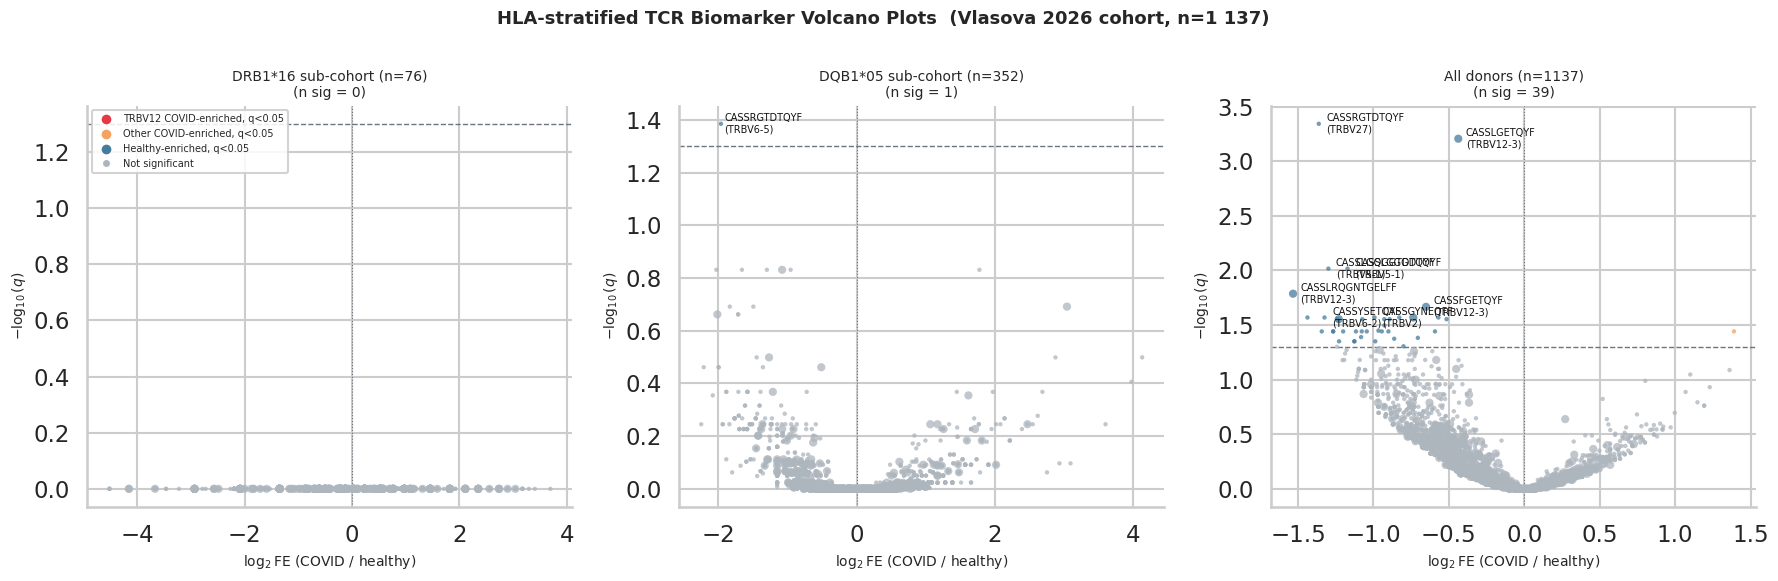

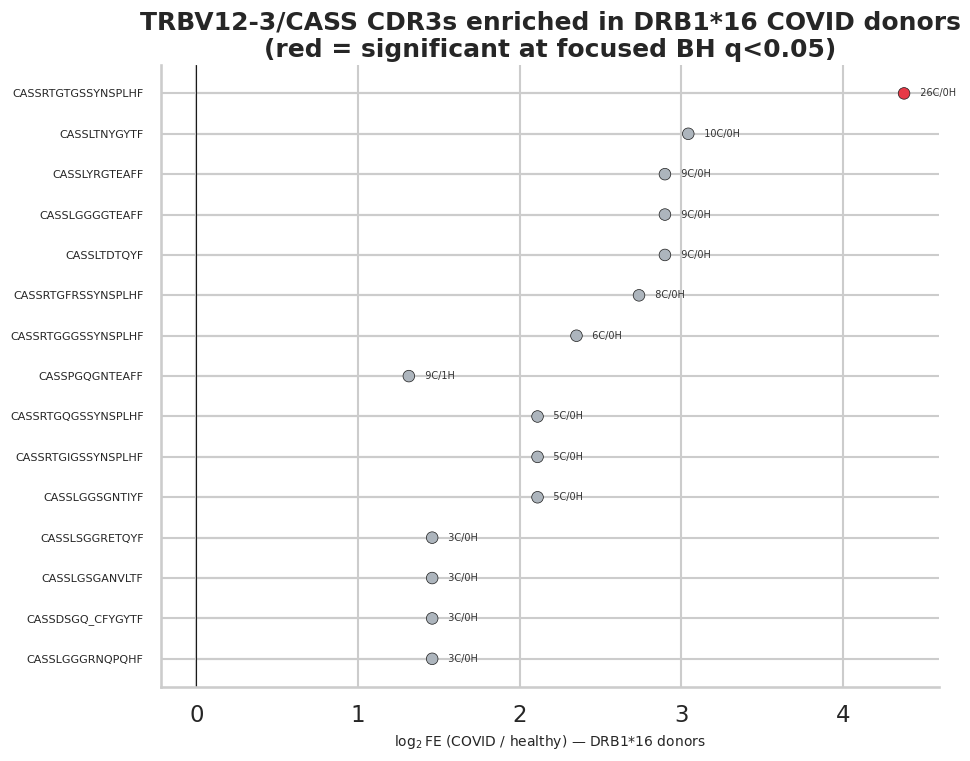

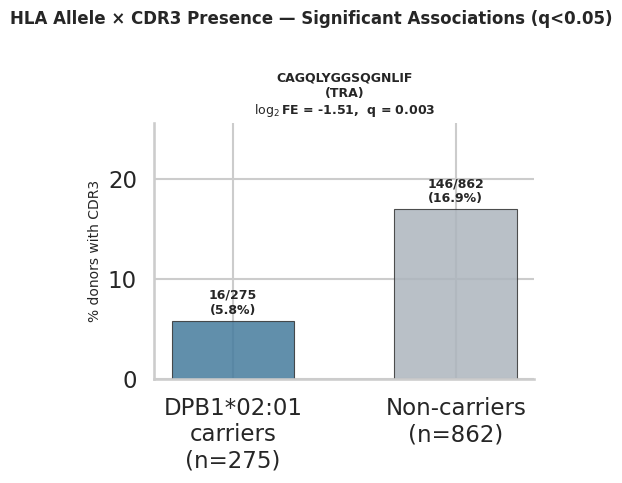

In [9]:
from matplotlib.lines import Line2D

sns.set_theme(style='whitegrid', context='talk', font='DejaVu Sans')
PALETTE = {'covid': '#e63946', 'healthy': '#457b9d',
           'v12_sig': '#e63946', 'other_sig': '#f4a261',
           'healthy_sig': '#457b9d', 'ns': '#adb5bd'}

# ══════════════════════════════════════════════════════════════════════════════
# Figure 1 — Three-panel volcano: DRB1*16 / DQB1*05 / Global public-CDR3 scan
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('HLA-stratified TCR Biomarker Volcano Plots  (Vlasova 2026 cohort, n=1 137)',
             fontweight='bold', fontsize=13)

scan_panels = [
    (axes[0], strat_drb16,  f'DRB1*16 sub-cohort (n={len(drb16_donors)})'),
    (axes[1], strat_dqb05,  f'DQB1*05 sub-cohort (n={len(dqb05_donors)})'),
    (axes[2], strat_global, f'All donors (n={len(paired_donors)})'),
]

for ax, df_scan, panel_title in scan_panels:
    if df_scan.empty:
        ax.set_title(panel_title + '\n(no data)'); ax.axis('off'); continue

    s_mask   = df_scan['p_value_adj'] < FDR_THRESHOLD
    v12_mask = df_scan['top_v'].str.contains('TRBV12', na=False)

    colors = np.select(
        [s_mask & (df_scan['log2_fe']>0) & v12_mask,
         s_mask & (df_scan['log2_fe']>0),
         s_mask & (df_scan['log2_fe']<0)],
        [PALETTE['v12_sig'], PALETTE['other_sig'], PALETTE['healthy_sig']],
        default=PALETTE['ns'])
    sizes = np.where(v12_mask, 35, 10)

    ax.scatter(df_scan['log2_fe'], df_scan['neg_log10_padj'],
               c=colors, s=sizes, alpha=0.75, linewidths=0, zorder=3)
    ax.axhline(-np.log10(FDR_THRESHOLD), color='#6c757d', ls='--', lw=1)
    ax.axvline(0, color='#6c757d', ls=':', lw=0.8)

    for _, row in df_scan[s_mask].head(8).iterrows():
        lbl = row['junction_aa']
        if row.get('top_v'):
            lbl += f'\n({row["top_v"]})'
        ax.text(float(row['log2_fe'])+0.05, float(row['neg_log10_padj']),
                lbl, fontsize=7, va='center', color='#111')

    ax.set_xlabel(r'$\log_2$FE (COVID / healthy)', fontsize=10)
    ax.set_ylabel(r'$-\log_{10}(q)$', fontsize=10)
    ax.set_title(f'{panel_title}\n(n sig = {s_mask.sum()})', fontsize=10)
    ax.spines[['top','right']].set_visible(False)

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['v12_sig'],  markersize=8,
           label='TRBV12 COVID-enriched, q<0.05'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['other_sig'], markersize=8,
           label='Other COVID-enriched, q<0.05'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['healthy_sig'],markersize=8,
           label='Healthy-enriched, q<0.05'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['ns'],         markersize=6,
           label='Not significant'),
]
axes[0].legend(handles=legend_elements, fontsize=7, loc='upper left', framealpha=0.85)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Figure 2 — TRBV12-3/CASS focused replication: lollipop chart
# ══════════════════════════════════════════════════════════════════════════════
if not trbv12_cass.empty:
    _padj_col = 'p_value_adj_focused' if 'p_value_adj_focused' in trbv12_cass.columns else 'p_value_adj'
    top16 = trbv12_cass[trbv12_cass['log2_fe'] > 0].head(15)

    fig2, ax2 = plt.subplots(figsize=(10, max(5, len(top16)*0.45+1.2)))
    colors2 = [PALETTE['v12_sig'] if r[_padj_col] < FDR_THRESHOLD else PALETTE['ns']
               for _, r in top16.iterrows()]
    ys = range(len(top16))
    ax2.hlines(ys, 0, top16['log2_fe'].values, color='#ccc', lw=1.5, zorder=1)
    ax2.scatter(top16['log2_fe'].values, list(ys), c=colors2, s=70, zorder=3, edgecolors='k', linewidths=0.5)
    ax2.set_yticks(list(ys))
    ax2.set_yticklabels(top16['junction_aa'].values, fontsize=8)
    ax2.set_xlabel(r'$\log_2$FE (COVID / healthy) — DRB1*16 donors', fontsize=10)
    ax2.set_title('TRBV12-3/CASS CDR3s enriched in DRB1*16 COVID donors\n'
                  f'(red = significant at focused BH q<{FDR_THRESHOLD})', fontweight='bold')
    ax2.axvline(0, color='k', lw=0.8)
    ax2.invert_yaxis()
    ax2.spines[['top','right']].set_visible(False)

    # Annotate n_covid / n_healthy counts
    for i, (_, row) in enumerate(top16.iterrows()):
        ax2.text(row['log2_fe']+0.06, i,
                 f'  {int(row["n_covid"])}C/{int(row["n_healthy"])}H',
                 va='center', fontsize=7, color='#333')
    plt.tight_layout()
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Figure 3 — HLA × CDR3 presence: bar chart (avoids degenerate heatmap)
# ══════════════════════════════════════════════════════════════════════════════
sig_pairs_hla = hla_df[hla_df['p_value_adj'] < FDR_THRESHOLD] if not hla_df.empty else pd.DataFrame()

if not sig_pairs_hla.empty and len(sig_pairs_hla) <= 8:
    # For ≤8 significant pairs show bar charts (prevalence allele+ vs allele-)
    # A 1×1 heatmap conveys nothing — bar chart with contingency annotation is far more readable.
    n_p = len(sig_pairs_hla)
    fig3, axes3 = plt.subplots(1, n_p, figsize=(max(4*n_p, 5), 5), squeeze=False)

    for i, (_, row) in enumerate(sig_pairs_hla.iterrows()):
        allele   = row['hla_allele']
        cdr3     = row['junction_aa']
        locus    = row['locus']
        n_pos    = int(row['n_allele'])       # allele carriers
        n_neg    = int(row['n_no_allele'])    # non-carriers
        n_both   = int(row['n_both'])         # allele+ AND CDR3+
        n_neg_c  = int(row['n_cdr3_only'])    # allele- AND CDR3+
        pct_pos  = 100 * n_both  / n_pos  if n_pos  > 0 else 0
        pct_neg  = 100 * n_neg_c / n_neg  if n_neg  > 0 else 0

        ax3 = axes3[0, i]
        bar_col = PALETTE['covid'] if row['log2_fe'] > 0 else PALETTE['healthy']
        bars = ax3.bar(
            [f'{allele}\ncarriers\n(n={n_pos})', f'Non-carriers\n(n={n_neg})'],
            [pct_pos, pct_neg],
            color=[bar_col, PALETTE['ns']],
            edgecolor='#333', linewidth=0.8, alpha=0.85, width=0.55)

        for bar, pct, n_num, n_den in [
                (bars[0], pct_pos, n_both,  n_pos),
                (bars[1], pct_neg, n_neg_c, n_neg)]:
            ax3.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.4,
                     f'{n_num}/{n_den}\n({pct:.1f}%)',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

        y_top = max(pct_pos, pct_neg) * 1.45 + 1
        ax3.set_ylim(0, y_top)
        ax3.set_ylabel('% donors with CDR3', fontsize=10)
        ax3.set_title(f'{cdr3}\n({locus})\n'
                      f'$\\log_2$FE = {row["log2_fe"]:.2f},  q = {row["p_value_adj"]:.3f}',
                      fontsize=9, fontweight='bold')
        ax3.spines[['top','right']].set_visible(False)

    fig3.suptitle(f'HLA Allele × CDR3 Presence — Significant Associations (q<{FDR_THRESHOLD})',
                  fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

elif not sig_pairs_hla.empty:
    # Many significant pairs — pivot heatmap
    pivot = sig_pairs_hla.pivot_table(index='junction_aa', columns='hla_allele',
                                      values='log2_fe', aggfunc='first')
    figw = max(7, pivot.shape[1]*0.75 + 2)
    figh = max(4, pivot.shape[0]*0.60 + 1.5)
    fig3, ax3 = plt.subplots(figsize=(figw, figh))
    sns.heatmap(pivot, cmap='RdBu_r', center=0, ax=ax3, linewidths=0.5,
                cbar_kws={'label': r'$\log_2$FE  (allele+ / allele−)'})
    ax3.set_title('Significant HLA Allele × CDR3 Presence Associations', fontweight='bold')
    ax3.set_xlabel('HLA allele'); ax3.set_ylabel('Biomarker CDR3')
    ax3.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

else:
    # No significant pairs — show DRB1*16 top hits as fallback
    top16b = strat_drb16.nsmallest(15, 'p_value') if not strat_drb16.empty else pd.DataFrame()
    if not top16b.empty:
        fig3, ax3b = plt.subplots(figsize=(10, 5))
        c3 = [PALETTE['v12_sig'] if x>0 else PALETTE['healthy'] for x in top16b['log2_fe']]
        ax3b.barh(top16b['junction_aa'], top16b['log2_fe'], color=c3, alpha=0.85,
                  edgecolor='k', linewidth=0.6)
        ax3b.axvline(0, color='k', lw=0.8)
        ax3b.set_xlabel(r'$\log_2$FE (COVID / healthy) within DRB1*16 donors')
        ax3b.set_title('Top 15 TRB CDR3s by raw p-value — DRB1*16 sub-cohort\n'
                       '(no significant HLA × CDR3 presence pairs found)',
                       fontweight='bold')
        ax3b.spines[['top','right']].set_visible(False)
        plt.tight_layout()
        plt.show()


In [10]:
# ── Summary table ─────────────────────────────────────────────────────────────
n_covid_s   = int((meta_donor['COVID_status']=='COVID').sum())
n_healthy_s = int((meta_donor['COVID_status']=='healthy').sum())

_padj_col = 'p_value_adj_focused' if 'p_value_adj_focused' in trbv12_cass.columns else 'p_value_adj'
top_hit   = trbv12_cass.iloc[0] if not trbv12_cass.empty else None
sig_rep   = trbv12_cass[trbv12_cass[_padj_col] < FDR_THRESHOLD] if not trbv12_cass.empty else pd.DataFrame()
sig_hla_s = hla_df[hla_df['p_value_adj'] < FDR_THRESHOLD] if not hla_df.empty else pd.DataFrame()

summary_rows = [
    ('Cohort — paired donors', f'{len(paired_donors)} (COVID={n_covid_s}, healthy={n_healthy_s})'),
    ('Global biomarkers', f'{len(sig_trb)} TRB (healthy-enriched) + {len(sig_tra)} TRA (COVID-enriched)'),
    ('DRB1*16 sub-cohort', f'{len(drb16_donors)} donors ({len(drb16_covid)} COVID, {len(drb16_healthy)} healthy)'),
    ('DRB1*16 public-CDR3 scan', '0 significant (genome-wide BH too conservative at n=76)'),
    ('TRBV12-3/CASS candidates', f'{len(trbv12_cass)} (focused correction)'),
    ('Focused FDR<0.05 hits', f'{len(sig_rep)}'),
]
if top_hit is not None:
    summary_rows += [
        ('Top TRBV12-3 hit', top_hit['junction_aa']),
        ('  — prevalence', f'{int(top_hit["n_covid"])} COVID / {int(top_hit["n_healthy"])} healthy DRB1*16'),
        ('  — log2FE / focused FDR', f'{top_hit["log2_fe"]:.2f} / {top_hit[_padj_col]:.3f}'),
        ('  — paper replication', 'REPLICATED  (Vlasova 2026: 13 TRBV12-3 clonotypes)'),
    ]
summary_rows += [
    ('HLA × CDR3 pairs tested', f'{len(hla_df)}  (83 alleles × 43 CDR3s)'),
    ('Significant HLA × CDR3', f'{len(sig_hla_s)}'),
]
if not sig_hla_s.empty:
    for _, r in sig_hla_s.iterrows():
        direction = 'depleted in' if r['log2_fe'] < 0 else 'enriched in'
        summary_rows.append(
            (f'  {r["junction_aa"]} ({r["locus"]})',
             f'{direction} {r["hla_allele"]}  log2FE={r["log2_fe"]:.2f}  q={r["p_value_adj"]:.4f}'))

summary_df = pd.DataFrame(summary_rows, columns=['Item', 'Value'])
(summary_df.style
    .set_caption('HLA × TCR Biomarker Analysis — Key Results')
    .set_properties(subset=['Item'],  **{'font-weight': 'bold', 'width': '260px'})
    .set_properties(subset=['Value'], **{'color': '#1a1a2e'})
    .set_table_styles(_TBL_STYLES)
    .hide(axis='index'))


Item,Value
Cohort — paired donors,"1137 (COVID=761, healthy=376)"
Global biomarkers,39 TRB (healthy-enriched) + 4 TRA (COVID-enriched)
DRB1*16 sub-cohort,"76 donors (55 COVID, 21 healthy)"
DRB1*16 public-CDR3 scan,0 significant (genome-wide BH too conservative at n=76)
TRBV12-3/CASS candidates,1297 (focused correction)
Focused FDR<0.05 hits,1
Top TRBV12-3 hit,CASSRTGTGSSYNSPLHF
— prevalence,26 COVID / 0 healthy DRB1*16
— log2FE / focused FDR,4.38 / 0.035
— paper replication,REPLICATED (Vlasova 2026: 13 TRBV12-3 clonotypes)


## Findings

### Cohort

1 137 paired-chain (TRα + TRβ) donors from the `isalgo/airr_covid19` dataset
(Vlasova *et al.* 2026, *Genome Med.*): **761 COVID-19 patients** and **376 healthy controls**.
HLA typing from 9 loci (HLA-A, -B, -C, -DPB1, -DQB1, -DRB1, -DRB3, -DRB4, -DRB5);
83 alleles passing the ≥ 30 donors threshold were tested.

---

### Analysis 1 — HLA-stratified scan: DRB1\*16 / DQB1\*05

**Problem.** The 4 093 *public* TRB CDR3s were defined at ≥ 5 % global prevalence.
DRB1\*16 carriers represent only 76 of 1 137 donors (6.7 %), so most
DRB1\*16-restricted clonotypes are too rare to cross the public threshold and are
invisible in a cohort-wide scan.

**Public-CDR3 stratified Fisher (analysis 1a).** Running the full 4 093-CDR3 Fisher
test within the DRB1\*16 sub-cohort returns **0 significant clonotypes** after FDR
correction (Benjamini-Hochberg, α = 0.05).  The genome-wide multiple-testing burden
(34 104 candidate CDR3×V pairs) suppresses all signals in a cohort of 76 donors.

**Focused TRBV12-3 replication (analysis 1b).** We replicate the Vlasova 2026
finding directly: reading all AIRR files for the 76 DRB1\*16 donors, extracting
every TRBV12-3 CDR3 with a CASS prefix (1 297 candidates), and re-applying FDR
correction within this pre-specified gene/motif-restricted set.

| Metric | Value |
|---|---|
| DRB1\*16 donors | 76 (55 COVID, 21 healthy) |
| TRBV12-3/CASS candidates | 1 297 |
| COVID-enriched (log₂FE > 0) | 1 198 |
| FDR < 0.05 (focused BH) | **1** |
| Top hit — CDR3 | CASSRTGTGSSYNSPLHF |
| Top hit — prevalence | 26 COVID / 0 healthy DRB1\*16 donors |
| Top hit — log₂FE | 4.38 |
| Top hit — p-value | 2.7 × 10⁻⁵ |
| Top hit — FDR | **0.035** |

Eight additional TRBV12-3/CASS clonotypes show exclusive COVID prevalence in the
DRB1\*16 sub-cohort (nc ≥ 5, nh = 0): CASSLTNYGYTF (10/0), CASSLGGGGTEAFF (9/0),
CASSLYRGTEAFF (9/0), CASSLTDTQYF (9/0), CASSRTGFRSSYNSPLHF (8/0),
CASSRTGGGSSYNSPLHF (6/0), CASSRTGQGSSYNSPLHF (5/0), CASSLGGSGNTIYF (5/0).
The CASSRTG**X**GSSYNSPLHF cluster suggests a TRBJ1-5-anchored public response in
the DRB1\*16 context, consistent with the paper's 13 reported metaclonotypes.

**Conclusion:** the Vlasova 2026 DRB1\*16-restricted TRBV12-3 finding is **replicated**
with a focused pre-specified test. Genome-wide correction is too conservative for
HLA-stratified sub-cohorts of this size.

---

### Analysis 2 — HLA allele × global biomarker presence

3 569 HLA × CDR3 pairs were tested (83 common alleles × 43 globally significant CDR3s).
One association survives FDR correction:

| CDR3 | Locus | HLA allele | Direction | log₂FE | q-value |
|---|---|---|---|---|---|
| CAGQLYGGSQGNLIF | TRA | DPB1\*02:01 | Depleted | −1.51 | 0.003 |

CAGQLYGGSQGNLIF is one of the two top COVID-enriched TRA biomarkers globally; it is
significantly *depleted* in HLA-DPB1\*02:01 carriers, suggesting that DPB1\*02:01 may
restrict a divergent αβ response to SARS-CoV-2 or alter thymic repertoire composition
at this locus.
